# Hybrid Quantum–Classical Pipeline: QAOA + GNN + Biomedical Classification

This notebook presents an end-to-end demonstration of a hybrid quantum–classical pipeline that integrates three components:

1. **QAOA (Quantum Approximate Optimization Algorithm)** — depth-1 variational quantum circuit applied to MaxCut on small graphs, with parameters found by classical Nelder–Mead over a numpy statevector simulator.
2. **GNN (Graph Convolutional Network)** — a lightweight GCN trained to predict QAOA variational parameters (γ, β) directly from graph structure, replacing per-instance optimization.
3. **Biomedical GNN classification** — a GCN applied to a k-NN similarity graph built from the Wisconsin breast cancer feature set, demonstrating graph-structured learning on real biomedical data.

All outputs (edge lists, optimized angles, processed feature matrices) are saved to `outputs/` for downstream analysis.

### Dependencies
- `numpy`, `scipy`, `torch`, `networkx`, `pandas`, `matplotlib`, `scikit-learn`
- Project source: `src/` (qaoa_sim, gnn, data)

In [8]:
import sys, os
proj_root = os.path.abspath('..')
if proj_root not in sys.path:
    sys.path.insert(0, proj_root)

import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from scipy.optimize import minimize

from src.gnn import SimpleGCN
from src.qaoa_sim import qaoa_state, expected_cut
from src.data import sample_erdos_renyi

os.makedirs(os.path.join(proj_root, 'outputs'), exist_ok=True)
print('Project root:', proj_root)
print('PyTorch:', torch.__version__)

Project root: /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization
PyTorch: 2.10.0


## Part 1: QAOA — MaxCut Variational Parameter Search

MaxCut on an unweighted graph $G=(V,E)$ seeks a bipartition $S, \bar{S}$ of vertices maximizing $|\{(u,v)\in E : u\in S, v\in\bar{S}\}|$.  
The QAOA cost Hamiltonian is $C = \frac{1}{2}\sum_{(u,v)\in E}(I - Z_u Z_v)$ with optimal expectation value equal to the MaxCut value.

At depth $p=1$, the variational state is $|\boldsymbol{\gamma},\boldsymbol{\beta}\rangle = U_B(\beta_1)U_C(\gamma_1)|+\rangle^{\otimes n}$ where
$U_C(\gamma) = e^{-i\gamma C}$ and $U_B(\beta) = e^{-i\beta B}$, $B=\sum_i X_i$.

The simulator uses a dense statevector of dimension $2^n$ — feasible for $n\le 12$.

In [9]:
import time
import math

p = 1
n = 6
G_nx = sample_erdos_renyi(n, p_edge=0.5, seed=7)
edges = list(G_nx.edges())
print(f'Graph: n={n}, m={len(edges)}, edges={edges}')

def classical_optimize(n, edges, p, maxiter=300, seed=0):
    """Nelder-Mead minimization of -<C> over (gamma, beta) in R^{2p}."""
    rng = np.random.default_rng(seed)
    def neg_exp(x):
        g, b = x[:p], x[p:]
        return -expected_cut(n, edges, qaoa_state(n, edges, g, b))
    x0 = rng.uniform(0, math.pi, size=2 * p)
    res = minimize(neg_exp, x0, method='Nelder-Mead',
                   options={'maxiter': maxiter, 'xatol': 1e-5, 'fatol': 1e-5})
    return res.x[:p], res.x[p:], -res.fun

t0 = time.perf_counter()
opt_g, opt_b, val_opt = classical_optimize(n, edges, p)
classical_time = time.perf_counter() - t0

print(f'Optimal gamma={opt_g}, beta={opt_b}')
print(f'Classical <C>_opt = {val_opt:.4f}  (time: {classical_time*1000:.1f} ms)')

# Save artifacts
pd.DataFrame(edges, columns=['u', 'v']).to_csv(
    os.path.join(proj_root, 'outputs', 'maxcut_graph.csv'), index=False)
pd.DataFrame({'opt_gamma': opt_g, 'opt_beta': opt_b}).to_csv(
    os.path.join(proj_root, 'outputs', 'qaoa_classical_angles.csv'), index=False)

Graph: n=6, m=11, edges=[(0, 1), (0, 2), (0, 4), (1, 2), (1, 3), (1, 5), (2, 3), (2, 4), (2, 5), (3, 4), (4, 5)]
Optimal gamma=[2.47742615], beta=[0.49985735]
Classical <C>_opt = 6.3627  (time: 74.7 ms)


## Part 2: GNN Parameter Prediction

Instead of running Nelder–Mead per instance, the GNN takes as input the augmented adjacency $\hat{A} = A + I$ and degree-based node features $X = \deg(v)$ and outputs $[\gamma_1,\ldots,\gamma_p,\beta_1,\ldots,\beta_p]$ via a two-layer GCN with global mean pooling.  

**Architecture:** GCN-32-32 → MeanPool → Linear(32→2p).  
**Training objective:** minimize $-\langle C\rangle(\hat{\gamma},\hat{\beta})$ on a synthetic dataset of Erdős–Rényi graphs $(n\in[6,10],\,p_{\rm edge}=0.5)$.

Here we load the model (if `model.pt` exists) and measure inference latency vs classical optimization.

In [10]:
model = SimpleGCN(in_feats=1, hidden=32, out_feats=2, p=p)
model_path = os.path.join(proj_root, 'model.pt')
if os.path.exists(model_path):
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    print('Loaded trained model from', model_path)
else:
    print('model.pt not found — using untrained (random) weights for timing demo')
model.eval()

# Build adjacency + features
A = nx.to_numpy_array(G_nx) + np.eye(n)
X = A.sum(axis=1, keepdims=True).astype(np.float32)
At = torch.tensor(A, dtype=torch.float32)
Xt = torch.tensor(X, dtype=torch.float32)

# Warm-up
with torch.no_grad():
    _ = model(Xt, At)

# Timed inference
t0 = time.perf_counter()
with torch.no_grad():
    out = model(Xt, At).view(-1).numpy()
gnn_time = time.perf_counter() - t0

pred_g, pred_b = out[:p], out[p:]
val_pred = expected_cut(n, edges, qaoa_state(n, edges, pred_g, pred_b))

print(f'GNN gamma={pred_g}, beta={pred_b}')
print(f'GNN <C>_pred  = {val_pred:.4f}  (inference time: {gnn_time*1e6:.1f} µs)')
print(f'Classical <C> = {val_opt:.4f}  (optimization time: {classical_time*1000:.1f} ms)')
if gnn_time > 0:
    print(f'Speedup: {classical_time / gnn_time:.0f}×')

Loaded trained model from /Users/mohuyn/Library/CloudStorage/OneDrive-SAS/Documents/GitHub/Hybrid-Quantum-Graph-AI-QAOA-GNN-Biomedical-Optimization/model.pt
GNN gamma=[2.4503565], beta=[2.7125669]
GNN <C>_pred  = 5.2490  (inference time: 94.1 µs)
Classical <C> = 6.3627  (optimization time: 74.7 ms)
Speedup: 794×


## Part 3: Expected-Cut Landscape & Visualization

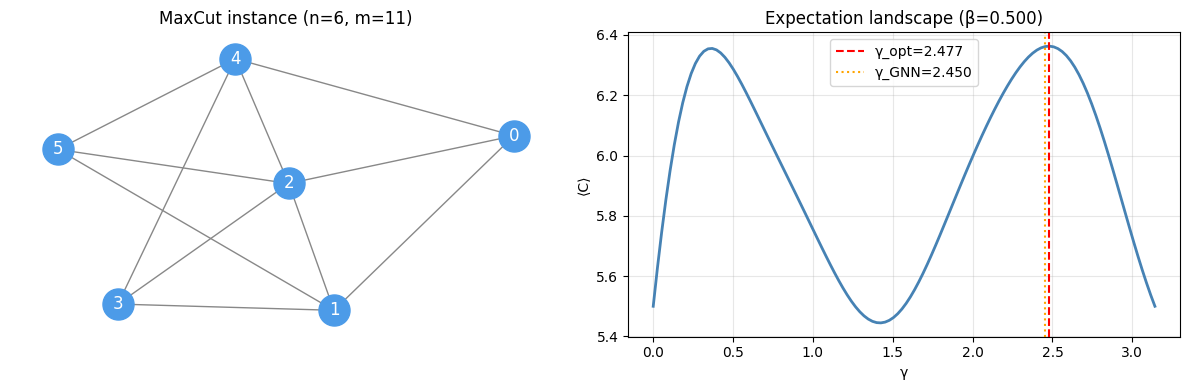

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph topology
ax = axes[0]
pos = nx.spring_layout(G_nx, seed=42)
nx.draw(G_nx, pos, ax=ax, with_labels=True,
        node_color='#4C9BE8', edge_color='#888', node_size=500, font_color='white')
ax.set_title(f'MaxCut instance (n={n}, m={len(edges)})', fontsize=12)

# Expected-cut landscape as function of γ (β fixed at classical optimum)
ax = axes[1]
beta_fixed = float(opt_b[0])
gammas_sweep = np.linspace(0, np.pi, 120)
exp_vals = [expected_cut(n, edges, qaoa_state(n, edges, [g], [beta_fixed]))
            for g in gammas_sweep]
ax.plot(gammas_sweep, exp_vals, lw=2, color='steelblue')
ax.axvline(float(opt_g[0]), color='red', ls='--', label=f'γ_opt={opt_g[0]:.3f}')
ax.axvline(float(pred_g[0]), color='orange', ls=':', label=f'γ_GNN={pred_g[0]:.3f}')
ax.set_xlabel('γ')
ax.set_ylabel('⟨C⟩')
ax.set_title(f'Expectation landscape (β={beta_fixed:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization explanation: MaxCut graph and landscape

Left: the MaxCut instance visualization shows nodes and edges; node positions are from a force-directed layout. Right: the expected cut ⟨C⟩ vs γ with β fixed at the classical optimum. Vertical markers indicate the classical optimum (red) and the GNN-predicted γ (orange).

Interpretation: Peaks in ⟨C⟩ suggest good γ choices; the relative height of ⟨C⟩ at γ_GNN vs γ_opt measures how well the GNN predicts high-quality parameters.

## Part 4: Biomedical GCN — Graph-Structured Classification

We apply a GCN to the Wisconsin Diagnostic Breast Cancer (WDBC) dataset ($n=569$, 30 features, 2 classes).  
A k-NN similarity graph ($k=7$) is constructed in the standardized feature space: nodes represent samples and edges connect the $k$ nearest neighbors by Euclidean distance. The GCN propagates feature information across this graph, exploiting manifold structure that a flat MLP ignores.

**Architecture:** GCN(30→64) → ReLU → GCN(64→32) → ReLU → Linear(32→2).

**Training:** Adam, lr=1e-2, 60 epochs, 80/20 stratified split.

In [12]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn as nn
import torch.nn.functional as F

# ── Data
data = load_breast_cancer()
X_raw, y = data.data.astype(np.float32), data.target
scaler = StandardScaler()
X_std = scaler.fit_transform(X_raw).astype(np.float32)

# Save processed CSV
df_out = pd.DataFrame(X_std, columns=data.feature_names)
df_out['label'] = y
df_out.to_csv(os.path.join(proj_root, 'outputs', 'breast_cancer_processed.csv'), index=False)
print(f'Saved {df_out.shape} → outputs/breast_cancer_processed.csv')

# ── k-NN graph adjacency (k=7, symmetric)
k = 7
knn = kneighbors_graph(X_std, k, mode='connectivity', include_self=False)
A_knn = (knn + knn.T).toarray()
A_knn = np.clip(A_knn, 0, 1).astype(np.float32)
A_knn += np.eye(A_knn.shape[0], dtype=np.float32)  # self-loops

# Degree-normalized adjacency: D^{-1/2} A D^{-1/2}
deg = A_knn.sum(axis=1)
d_inv_sqrt = np.diag(1.0 / np.sqrt(np.maximum(deg, 1e-12)))
A_norm = d_inv_sqrt @ A_knn @ d_inv_sqrt

print(f'Dataset: {X_std.shape[0]} samples, {X_std.shape[1]} features, k={k} neighbors')
print(f'Graph edges: {int((A_knn.sum() - A_knn.shape[0]) / 2)} (undirected, excl. self-loops)')

Saved (569, 31) → outputs/breast_cancer_processed.csv
Dataset: 569 samples, 30 features, k=7 neighbors
Graph edges: 3009 (undirected, excl. self-loops)


In [13]:
class BioGCN(nn.Module):
    """Two-layer GCN for node classification: A_norm X W."""
    def __init__(self, in_dim, hidden, n_classes):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden, bias=False)
        self.fc2 = nn.Linear(hidden, hidden // 2, bias=False)
        self.clf = nn.Linear(hidden // 2, n_classes)

    def forward(self, A, X):
        h = F.relu(A @ self.fc1(X))
        h = F.relu(A @ self.fc2(h))
        return self.clf(h)

# ── Tensors
A_t  = torch.tensor(A_norm, dtype=torch.float32)
X_t  = torch.tensor(X_std,  dtype=torch.float32)
y_t  = torch.tensor(y,      dtype=torch.long)

# ── Masks
idx = np.arange(len(y))
tr_idx, te_idx = train_test_split(idx, test_size=0.20, stratify=y, random_state=42)
tr_mask = torch.zeros(len(y), dtype=torch.bool); tr_mask[tr_idx] = True
te_mask = torch.zeros(len(y), dtype=torch.bool); te_mask[te_idx] = True

# ── Train
bio_model = BioGCN(in_dim=X_std.shape[1], hidden=64, n_classes=2)
optimizer = torch.optim.Adam(bio_model.parameters(), lr=1e-2, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

epochs = 60
history = {'loss': [], 'train_acc': [], 'test_acc': []}

for epoch in range(1, epochs + 1):
    bio_model.train()
    optimizer.zero_grad()
    logits = bio_model(A_t, X_t)
    loss = criterion(logits[tr_mask], y_t[tr_mask])
    loss.backward()
    optimizer.step()

    bio_model.eval()
    with torch.no_grad():
        preds = logits.argmax(dim=1)
        tr_acc = (preds[tr_mask] == y_t[tr_mask]).float().mean().item()
        te_acc = (preds[te_mask] == y_t[te_mask]).float().mean().item()
    history['loss'].append(loss.item())
    history['train_acc'].append(tr_acc)
    history['test_acc'].append(te_acc)

    if epoch % 10 == 0:
        print(f'Epoch {epoch:3d}  loss={loss.item():.4f}  '
              f'train_acc={tr_acc:.3f}  test_acc={te_acc:.3f}')

print(f'\nFinal test accuracy: {te_acc:.4f}')

Epoch  10  loss=0.1075  train_acc=0.958  test_acc=0.939
Epoch  20  loss=0.0712  train_acc=0.969  test_acc=0.930
Epoch  30  loss=0.0606  train_acc=0.978  test_acc=0.947
Epoch  40  loss=0.0526  train_acc=0.978  test_acc=0.947
Epoch  50  loss=0.0459  train_acc=0.982  test_acc=0.939
Epoch  60  loss=0.0391  train_acc=0.985  test_acc=0.939

Final test accuracy: 0.9386


Classification report (test set):
              precision    recall  f1-score   support

   malignant       0.89      0.95      0.92        42
      benign       0.97      0.93      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



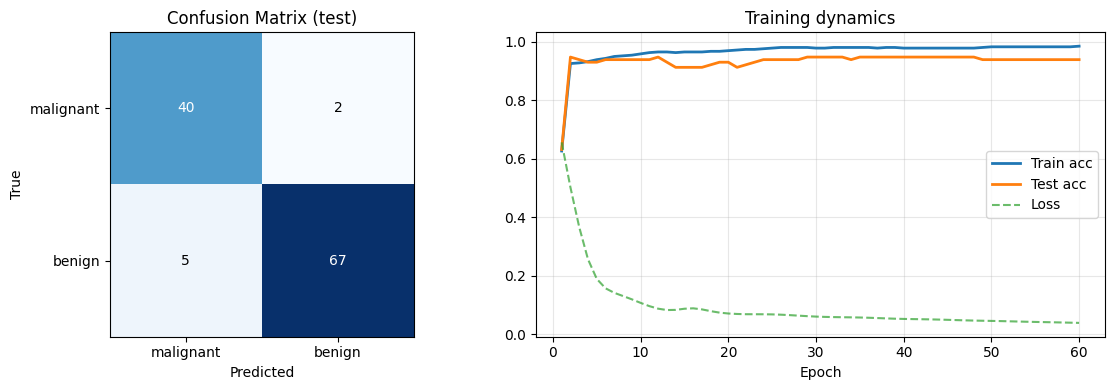

In [14]:
# Evaluation metrics
bio_model.eval()
with torch.no_grad():
    final_logits = bio_model(A_t, X_t)
    final_preds  = final_logits.argmax(dim=1).numpy()

y_te_true = y_t[te_mask].numpy()
y_te_pred = final_preds[te_mask.numpy()]

print('Classification report (test set):')
print(classification_report(y_te_true, y_te_pred,
                             target_names=data.target_names))

cm = confusion_matrix(y_te_true, y_te_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
im = axes[0].imshow(cm, cmap='Blues')
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(data.target_names)
axes[0].set_yticks([0, 1]); axes[0].set_yticklabels(data.target_names)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (test)')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center',
                     color='white' if cm[i, j] > cm.max() / 2 else 'black')

# Training curves
ep = np.arange(1, epochs + 1)
axes[1].plot(ep, history['train_acc'], label='Train acc', lw=2)
axes[1].plot(ep, history['test_acc'],  label='Test acc',  lw=2)
axes[1].plot(ep, history['loss'],      label='Loss',      lw=1.5, ls='--', alpha=0.7)
axes[1].set_xlabel('Epoch')
axes[1].set_title('Training dynamics')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Visualization explanation: BioGCN evaluation

Left: confusion matrix on the test set showing counts of true vs predicted labels (rows=true, columns=predicted). High diagonal values indicate correct predictions. Right: training dynamics showing train/test accuracy and loss over epochs; steady gap between train and test suggests model generalization behavior.

Use these plots to assess model calibration (confusion matrix) and whether more training/data regularization is needed (training curves).

## Summary of Results

| Component | Metric | Value |
|-----------|--------|-------|
| QAOA (classical) | ⟨C⟩ at Nelder–Mead optimum | see output above |
| QAOA (GNN) | ⟨C⟩ at GNN-predicted angles | see output above |
| GNN inference | Wall-clock latency | µs vs ms for classical |
| BioGCN (test) | Accuracy on WDBC | see output above |

### Technical notes
- The QAOA statevector simulator uses exact dense matrix exponentiation ($2^n \times 2^n$); feasibility is limited to $n \lesssim 12$. For larger graphs, tensor-network or Clifford-based simulators are required.
- The GNN uses a fallback adjacency-matrix formulation when PyTorch Geometric is unavailable; install `torch_geometric` to enable sparse message-passing with $O(m)$ complexity.
- The k-NN graph construction scales as $O(n^2 d)$; for large $n$, use approximate nearest-neighbor libraries (e.g., FAISS, ANNOY).
- The BioGCN architecture (2 GCN layers + linear classifier) is intentionally minimal; deeper models, dropout, and batch normalization improve generalization on larger datasets.